<a href="https://colab.research.google.com/github/Sumitsharma12321/fake-news-cross-generalization/blob/main/Fake_News_BILSTM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# BiLSTM Fake News Detection

 Project: Cross-Generalization and Explainability Analysis of
 Fake News Detectors Under LLM-Generated Style Attacks

In [1]:
import os
import re
import json
import  random
import  joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


# **Configuration and Random Seed**

In [2]:
RANDOM_STATE = 42

random.seed(RANDOM_STATE)

np.random.seed(RANDOM_STATE)

torch.manual_seed(RANDOM_STATE)

torch.cuda.manual_seed_all(RANDOM_STATE)



In [3]:
LABEL_REAL, LABEL_FAKE = 0, 1

MAX_VOCAB_SIZE = 50_000
EMBEDDING_DIM = 100
MAX_SEQ_LEN = 300      # justified in Section 6
HIDDEN_DIM = 64
BATCH_SIZE = 64
EPOCHS = 15
LEARNING_RATE = 1e-3
PATIENCE = 3           # early stopping



In [4]:

from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [5]:
import pandas as pd

SPLITS_DIR = "/content/drive/MyDrive/FakeNews_Project/splits"

train_df = pd.read_csv(f"{SPLITS_DIR}/train.csv")
val_df   = pd.read_csv(f"{SPLITS_DIR}/val.csv")
test_df  = pd.read_csv(f"{SPLITS_DIR}/test.csv")
ood_df   = pd.read_csv(f"{SPLITS_DIR}/megafake_ood_test.csv")

train_df["text"] = train_df["text"].fillna("")
val_df["text"]   = val_df["text"].fillna("")
test_df["text"]  = test_df["text"].fillna("")

print("Train:", train_df.shape, "Val:", val_df.shape, "Test:", test_df.shape, "OOD:", ood_df.shape)

Train: (27371, 2) Val: (5866, 2) Test: (5866, 2) OOD: (1500, 3)


In [6]:
import os

BILSTM_DIR = "/content/drive/MyDrive/FakeNews_Project/BiLSTM"
LIME_DIR = f"{BILSTM_DIR}/LIME"
os.makedirs(BILSTM_DIR, exist_ok=True)
os.makedirs(LIME_DIR, exist_ok=True)

print("Ready:", BILSTM_DIR)

Ready: /content/drive/MyDrive/FakeNews_Project/BiLSTM


# **Verify train test split**

In [7]:
print("Class balance:")
for name, df in [("Train", train_df), ("Val", val_df), ("Test", test_df)]:
    print(name, df["label"].value_counts(normalize=True).to_dict())

overlap = set(train_df["text"]) & set(test_df["text"])
print("Train/Test text overlap:", len(overlap))

Class balance:
Train {0: 0.5420335391472727, 1: 0.45796646085272735}
Val {0: 0.5421070576201841, 1: 0.45789294237981587}
Test {0: 0.5421070576201841, 1: 0.45789294237981587}
Train/Test text overlap: 1


# **Tokenization and Vocabulary**

In [8]:
from collections import Counter

def simple_tokenize(text):
    return re.findall(r"\b\w+\b", text.lower())

# Build vocabulary from TRAINING data only
counter = Counter()
for text in train_df["text"]:
    counter.update(simple_tokenize(text))

most_common = counter.most_common(MAX_VOCAB_SIZE - 2)  # reserve <PAD>, <OOV>
word2idx = {"<PAD>": 0, "<OOV>": 1}
for word, _ in most_common:
    word2idx[word] = len(word2idx)

vocab_size = len(word2idx)
print("Vocabulary size:", vocab_size)

lengths = train_df["text"].apply(lambda x: len(simple_tokenize(x)))
print(lengths.describe())
print("95th percentile length:", np.percentile(lengths, 95))

Vocabulary size: 50000
count    27371.000000
mean       419.354572
std        310.332316
min          0.000000
25%        227.000000
50%        388.000000
75%        534.000000
max       7398.000000
Name: text, dtype: float64
95th percentile length: 912.0


# **Sequence Conversion and Padding**


In [9]:
def text_to_sequence(text, word2idx, maxlen=MAX_SEQ_LEN):
    tokens = simple_tokenize(text)
    ids = [word2idx.get(tok, word2idx["<OOV>"]) for tok in tokens[:maxlen]]
    if len(ids) < maxlen:
        ids = ids + [word2idx["<PAD>"]] * (maxlen - len(ids))
    return ids

def texts_to_padded(texts, word2idx, maxlen=MAX_SEQ_LEN):
    return np.array([text_to_sequence(t, word2idx, maxlen) for t in texts], dtype=np.int64)

X_train_pad = texts_to_padded(train_df["text"], word2idx)
X_val_pad   = texts_to_padded(val_df["text"], word2idx)
X_test_pad  = texts_to_padded(test_df["text"], word2idx)

y_train = train_df["label"].values.astype(np.float32)
y_val   = val_df["label"].values.astype(np.float32)
y_test  = test_df["label"].values.astype(np.float32)

print(X_train_pad.shape, X_val_pad.shape, X_test_pad.shape)

(27371, 300) (5866, 300) (5866, 300)


# **Dataset and DataLoader Wrapper**

In [10]:
class NewsDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.long)
        self.y = torch.tensor(y, dtype=torch.float32)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_loader = DataLoader(NewsDataset(X_train_pad, y_train), batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(NewsDataset(X_val_pad, y_val), batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(NewsDataset(X_test_pad, y_test), batch_size=BATCH_SIZE, shuffle=False)

# **Pretrained Embedding Setup**

In [11]:
!wget -q http://nlp.stanford.edu/data/glove.6B.zip
!unzip -q glove.6B.zip glove.6B.100d.txt

embeddings_index = {}
with open("glove.6B.100d.txt", encoding="utf-8") as f:
    for line in f:
        values = line.split()
        word = values[0]
        vector = np.asarray(values[1:], dtype="float32")
        embeddings_index[word] = vector

print(f"Loaded {len(embeddings_index)} GloVe word vectors.")

embedding_matrix = np.random.normal(0, 0.1, (vocab_size, EMBEDDING_DIM)).astype("float32")
embedding_matrix[0] = np.zeros(EMBEDDING_DIM)  # <PAD> stays zero

found = 0
for word, idx in word2idx.items():
    vec = embeddings_index.get(word)
    if vec is not None:
        embedding_matrix[idx] = vec
        found += 1

print(f"Words found in GloVe: {found}/{vocab_size}")
embedding_tensor = torch.tensor(embedding_matrix, dtype=torch.float32)

Loaded 400000 GloVe word vectors.
Words found in GloVe: 45030/50000


# **BiLSTM Architecture**

In [12]:
class BiLSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, embedding_matrix, pad_idx=0):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=pad_idx)
        self.embedding.weight.data.copy_(embedding_matrix)
        self.embedding.weight.requires_grad = False  # frozen, same as Keras trainable=False

        self.lstm = nn.LSTM(embedding_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.dropout1 = nn.Dropout(0.4)
        self.fc1 = nn.Linear(hidden_dim * 2, 32)
        self.relu = nn.ReLU()
        self.dropout2 = nn.Dropout(0.3)
        self.fc2 = nn.Linear(32, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        emb = self.embedding(x)                     # (batch, seq_len, emb_dim)
        lstm_out, (h_n, c_n) = self.lstm(emb)
        # concat final forward + backward hidden states
        h_forward = h_n[0]
        h_backward = h_n[1]
        h_cat = torch.cat([h_forward, h_backward], dim=1)   # (batch, hidden_dim*2)

        x = self.dropout1(h_cat)
        x = self.relu(self.fc1(x))
        x = self.dropout2(x)
        x = self.fc2(x)
        return self.sigmoid(x).squeeze(1)

model = BiLSTMClassifier(vocab_size, EMBEDDING_DIM, HIDDEN_DIM, embedding_tensor).to(device)

In [13]:
print(model)
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total params: {total_params:,} | Trainable: {trainable_params:,}")

BiLSTMClassifier(
  (embedding): Embedding(50000, 100, padding_idx=0)
  (lstm): LSTM(100, 64, batch_first=True, bidirectional=True)
  (dropout1): Dropout(p=0.4, inplace=False)
  (fc1): Linear(in_features=128, out_features=32, bias=True)
  (relu): ReLU()
  (dropout2): Dropout(p=0.3, inplace=False)
  (fc2): Linear(in_features=32, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)
Total params: 5,089,153 | Trainable: 89,153


# **Training with Validation Monitoring**

In [14]:
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

best_val_loss = float("inf")
patience_counter = 0
history = {"train_loss": [], "val_loss": [], "val_f1": []}
checkpoint_path = f"{BILSTM_DIR}/best_bilstm.pt"

for epoch in range(EPOCHS):
    model.train()
    train_losses = []
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        preds = model(X_batch)
        loss = criterion(preds, y_batch)
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())

    model.eval()
    val_losses = []
    all_preds, all_labels = [], []
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            preds = model(X_batch)
            loss = criterion(preds, y_batch)
            val_losses.append(loss.item())
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y_batch.cpu().numpy())

    val_loss = np.mean(val_losses)
    val_f1 = f1_score(np.array(all_labels), (np.array(all_preds) >= 0.5).astype(int))

    history["train_loss"].append(np.mean(train_losses))
    history["val_loss"].append(val_loss)
    history["val_f1"].append(val_f1)

    print(f"Epoch {epoch+1}/{EPOCHS} - train_loss: {np.mean(train_losses):.4f} - val_loss: {val_loss:.4f} - val_f1: {val_f1:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), checkpoint_path)
        print("  -> Saved new best model")
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print("Early stopping triggered.")
            break

pd.DataFrame(history).to_csv(f"{BILSTM_DIR}/training_history.csv", index=False)

Epoch 1/15 - train_loss: 0.1696 - val_loss: 0.0072 - val_f1: 0.9981
  -> Saved new best model
Epoch 2/15 - train_loss: 0.0126 - val_loss: 0.0071 - val_f1: 0.9983
  -> Saved new best model
Epoch 3/15 - train_loss: 0.0092 - val_loss: 0.0057 - val_f1: 0.9985
  -> Saved new best model
Epoch 4/15 - train_loss: 0.0080 - val_loss: 0.0053 - val_f1: 0.9981
  -> Saved new best model
Epoch 5/15 - train_loss: 0.0086 - val_loss: 0.0048 - val_f1: 0.9985
  -> Saved new best model
Epoch 6/15 - train_loss: 0.0048 - val_loss: 0.0046 - val_f1: 0.9989
  -> Saved new best model
Epoch 7/15 - train_loss: 0.0048 - val_loss: 0.0042 - val_f1: 0.9993
  -> Saved new best model
Epoch 8/15 - train_loss: 0.0031 - val_loss: 0.0044 - val_f1: 0.9994
Epoch 9/15 - train_loss: 0.0053 - val_loss: 0.0040 - val_f1: 0.9994
  -> Saved new best model
Epoch 10/15 - train_loss: 0.0036 - val_loss: 0.0041 - val_f1: 0.9991
Epoch 11/15 - train_loss: 0.0020 - val_loss: 0.0037 - val_f1: 0.9991
  -> Saved new best model
Epoch 12/15 - tr

# **Best-Model Selection**

In [15]:
model.load_state_dict(torch.load(checkpoint_path))
model.eval()

val_probs, val_labels = [], []
with torch.no_grad():
    for X_batch, y_batch in val_loader:
        X_batch = X_batch.to(device)
        preds = model(X_batch).cpu().numpy()
        val_probs.extend(preds)
        val_labels.extend(y_batch.numpy())

val_preds = (np.array(val_probs) >= 0.5).astype(int)
val_f1 = f1_score(val_labels, val_preds)
print("Validation F1 (selection metric):", val_f1)

Validation F1 (selection metric): 0.9996276991809382


# **Human-ID Evaluation**

In [16]:
def evaluate_predictions(y_true, y_pred, y_proba, model_name, dataset_name):
    return {
        "Model": model_name,
        "Dataset": dataset_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1": f1_score(y_true, y_pred),
        "ROC-AUC": roc_auc_score(y_true, y_proba)
    }

test_probs, test_labels = [], []
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        preds = model(X_batch).cpu().numpy()
        test_probs.extend(preds)
        test_labels.extend(y_batch.numpy())

test_probs = np.array(test_probs)
test_preds = (test_probs >= 0.5).astype(int)
test_labels = np.array(test_labels)

bilstm_human_id_result = evaluate_predictions(test_labels, test_preds, test_probs, "BiLSTM", "Human-ID")
bilstm_human_id_df = pd.DataFrame([bilstm_human_id_result])
print(bilstm_human_id_df)

    Model   Dataset  Accuracy  Precision  Recall        F1   ROC-AUC
0  BiLSTM  Human-ID  0.998977   0.997771     1.0  0.998884  0.999926


# **Save Model and Preprocessing Artifacts**

In [18]:
torch.save(model.state_dict(), f"{BILSTM_DIR}/best_bilstm.pt")
joblib.dump(word2idx, f"{BILSTM_DIR}/word2idx.joblib")

config = {"MAX_SEQ_LEN": MAX_SEQ_LEN, "vocab_size": vocab_size,
          "EMBEDDING_DIM": EMBEDDING_DIM, "HIDDEN_DIM": HIDDEN_DIM,
          "RANDOM_STATE": RANDOM_STATE}

with open(f"{BILSTM_DIR}/config.json", "w") as f:
    json.dump(config, f, indent=2)

bilstm_human_id_df.to_csv(f"{BILSTM_DIR}/human_id_results.csv", index=False)
print("Saved BiLSTM artifacts to:", BILSTM_DIR)
print(os.listdir(BILSTM_DIR))

Saved BiLSTM artifacts to: /content/drive/MyDrive/FakeNews_Project/BiLSTM
['LIME', 'best_bilstm.pt', 'training_history.csv', 'word2idx.joblib', 'config.json', 'human_id_results.csv']


# **MegaFake OOD Preparation**

In [19]:
ood_df = pd.read_csv(f"{SPLITS_DIR}/megafake_ood_test.csv")
ood_df["content_clean"] = ood_df["content_clean"].fillna("")

print("MegaFake OOD samples:", ood_df.shape)
print(ood_df["label"].value_counts())

X_ood_pad = texts_to_padded(ood_df["content_clean"], word2idx)  # SAME vocab, lookup only
y_ood = ood_df["label"].values.astype(np.float32)
print("Real:", (y_ood == 0).sum(), " Fake:", (y_ood == 1).sum())

ood_loader = DataLoader(NewsDataset(X_ood_pad, y_ood), batch_size=BATCH_SIZE, shuffle=False)

MegaFake OOD samples: (1500, 3)
label
0    750
1    750
Name: count, dtype: int64
Real: 750  Fake: 750


# **MegaFake OOD Evaluation**

    Model       Dataset  Accuracy  Precision    Recall        F1   ROC-AUC
0  BiLSTM  MegaFake-OOD  0.507333   0.503714  0.994667  0.668758  0.634684


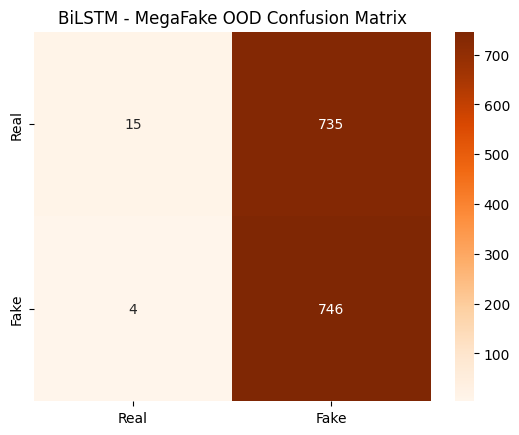

In [20]:
model.eval()
ood_probs, ood_labels = [], []
with torch.no_grad():
    for X_batch, y_batch in ood_loader:
        X_batch = X_batch.to(device)
        preds = model(X_batch).cpu().numpy()
        ood_probs.extend(preds)
        ood_labels.extend(y_batch.numpy())

ood_probs = np.array(ood_probs)
ood_preds = (ood_probs >= 0.5).astype(int)
ood_labels = np.array(ood_labels)

bilstm_ood_result = evaluate_predictions(ood_labels, ood_preds, ood_probs, "BiLSTM", "MegaFake-OOD")
bilstm_ood_df = pd.DataFrame([bilstm_ood_result])
print(bilstm_ood_df)

cm = confusion_matrix(ood_labels, ood_preds)
sns.heatmap(cm, annot=True, fmt="d", cmap="Oranges",
            xticklabels=["Real", "Fake"], yticklabels=["Real", "Fake"])
plt.title("BiLSTM - MegaFake OOD Confusion Matrix")
plt.savefig(f"{BILSTM_DIR}/bilstm_ood_confusion_matrix.png", dpi=150)
plt.show()

# **Generalization Gap**

In [21]:
bilstm_full_df = pd.concat([bilstm_human_id_df, bilstm_ood_df], ignore_index=True)

gap = bilstm_human_id_result["F1"] - bilstm_ood_result["F1"]
bilstm_gap_df = pd.DataFrame([{
    "Model": "BiLSTM",
    "F1_Human-ID": bilstm_human_id_result["F1"],
    "F1_OOD": bilstm_ood_result["F1"],
    "Generalization_Gap": gap
}])

print(bilstm_full_df)
print(bilstm_gap_df)

    Model       Dataset  Accuracy  Precision    Recall        F1   ROC-AUC
0  BiLSTM      Human-ID  0.998977   0.997771  1.000000  0.998884  0.999926
1  BiLSTM  MegaFake-OOD  0.507333   0.503714  0.994667  0.668758  0.634684
    Model  F1_Human-ID    F1_OOD  Generalization_Gap
0  BiLSTM     0.998884  0.668758            0.330126


# **LIME Explainability**

In [22]:
!pip install lime -q
from lime.lime_text import LimeTextExplainer

explainer = LimeTextExplainer(class_names=["REAL", "FAKE"], random_state=RANDOM_STATE)

def predict_proba_for_lime(texts):
    padded = texts_to_padded(texts, word2idx)
    X_tensor = torch.tensor(padded, dtype=torch.long).to(device)
    model.eval()
    with torch.no_grad():
        probs_fake = model(X_tensor).cpu().numpy()
    probs_real = 1 - probs_fake
    return np.column_stack([probs_real, probs_fake])

def explain_example(text, num_features=10):
    exp = explainer.explain_instance(text, predict_proba_for_lime, num_features=num_features)
    pred_proba = predict_proba_for_lime([text])[0]
    pred_label = int(np.argmax(pred_proba))
    return exp, pred_label, pred_proba

# Human-ID example (correctly classified)
correct_mask = (test_preds == test_labels)
idx_human = np.where(correct_mask)[0][0]
text_human = test_df["text"].iloc[idx_human]
exp_human, pred_h, proba_h = explain_example(text_human)
print("Human-ID true:", test_labels[idx_human], "pred:", pred_h, "proba:", proba_h)
exp_human.save_to_file(f"{LIME_DIR}/lime_bilstm_human_id.html")

# MegaFake OOD example — false positive (REAL predicted FAKE)
fp_mask = (ood_labels == 0) & (ood_preds == 1)
fp_indices = np.where(fp_mask)[0]
idx_ood = fp_indices[0] if len(fp_indices) > 0 else 0
text_ood = ood_df["content_clean"].iloc[idx_ood]
exp_ood, pred_o, proba_o = explain_example(text_ood)
print("OOD true:", ood_labels[idx_ood], "pred:", pred_o, "proba:", proba_o)
exp_ood.save_to_file(f"{LIME_DIR}/lime_bilstm_ood.html")

print("Top features - Human-ID:", exp_human.as_list())
print("Top features - OOD:", exp_ood.as_list())

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 5.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
Human-ID true: 0.0 pred: 0 proba: [9.9999988e-01 1.1610142e-07]
OOD true: 0.0 pred: 1 proba: [0.00111097 0.998889  ]
Top features - Human-ID: [(np.str_('reuters'), -0.7896913010714995), (np.str_('house'), -0.0604166001894589), (np.str_('apps'), -0.05378814290461725), (np.str_('google'), -0.048524291637553424), (np.str_('yahoo'), -0.04416728121523403), (np.str_('washington'), -0.03832079528093031), (np.str_('fears'), -0.03405843243507727), (np.str_('u'), -0.02781468250135192), (np.str_('s'), -0.027772009424006115), (np.str_('internal'), 0.019258097359224773)]
Top features - OOD: [(np.str_('news'), 0.00307567723880527), (np.str_('26'), -0.0026369934031282263), (np.str_('concept'), -0.002246011414701625), (np.str_('an'), 0.0021366820743643623), (np.str_('here'), 0.00206063828409507), (np.str_('highlighted'), -0.002045977902444825), (np.str_('he'), 0.001981073513351744)

# **ID vs OOD Feature Comparison**

In [23]:
K = 10
human_features = set([w for w, _ in exp_human.as_list()[:K]])
ood_features = set([w for w, _ in exp_ood.as_list()[:K]])

common = human_features & ood_features
id_only = human_features - ood_features
ood_only = ood_features - human_features

overlap_pct = len(common) / K * 100

feature_overlap_df = pd.DataFrame([{
    "Model": "BiLSTM",
    "Dataset": "Human-ID vs OOD",
    "Top_K": K,
    "Common_Features": ", ".join(common),
    "ID_Only_Features": ", ".join(id_only),
    "OOD_Only_Features": ", ".join(ood_only),
    "Overlap_Percent": overlap_pct
}])

print(feature_overlap_df)

    Model          Dataset  Top_K Common_Features  \
0  BiLSTM  Human-ID vs OOD     10                   

                                    ID_Only_Features  \
0  reuters, washington, apps, fears, u, house, in...   

                                   OOD_Only_Features  Overlap_Percent  
0  news, highlighted, day, concept, here, an, 26,...              0.0  


In [24]:
bilstm_full_df.to_csv(f"{BILSTM_DIR}/bilstm_full_comparison_results.csv", index=False)
bilstm_gap_df.to_csv(f"{BILSTM_DIR}/bilstm_generalization_gap.csv", index=False)
feature_overlap_df.to_csv(f"{LIME_DIR}/bilstm_lime_feature_overlap.csv", index=False)

print("All BiLSTM artifacts saved.")
print(os.listdir(BILSTM_DIR))
print(os.listdir(LIME_DIR))

All BiLSTM artifacts saved.
['LIME', 'best_bilstm.pt', 'training_history.csv', 'word2idx.joblib', 'config.json', 'human_id_results.csv', 'bilstm_ood_confusion_matrix.png', 'bilstm_full_comparison_results.csv', 'bilstm_generalization_gap.csv']
['lime_bilstm_human_id.html', 'lime_bilstm_ood.html', 'bilstm_lime_feature_overlap.csv']
